# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [78]:
import timeit
from timeit import Timer
import matplotlib.pyplot as plt
import math

%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [79]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [80]:
# Test rapide
a, b = 9, 4
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(9, 4) = 1
9*1 + 4*-2 = 1


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [81]:
def euclide_etendu_iter(a, b):
    """
    Version itérative de l'algorithme d'Euclide étendu.
    """     
    r=a%b
    u0 = 1;v0= 0;u1=0;v1=1
    while (r != 0) : # En boucle jusque le reste de la divison euclidien de a par b est 0
        # Utilisons la suite definie par recurrence
        u = u0 - u1*(a//b)
        v = v0 - v1*(a//b)
        # Mise a jour des coefficients
        u0 = u1
        u1 = u
        v0 = v1
        v1 = v
        a = b
        b = r
        r = a%b
    return(b,u,v) # on retourne le dernier reste non nul stoker dans b
    pass

In [82]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [83]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.

    """
    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]

In [84]:
# Test
print(eratosthene(100))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [85]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """

    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                if (est_premier[multiple] == False) : # Tester si c'est deja un multiple de 2
                    continue # si oui,on continue l'alteration suivant
                else :
                    est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]

    pass

In [86]:
print(eratosthene_opt(100))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [87]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [88]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s\n")
    print(f"n = {n:7d} : temps opt = {t_opt:.4f} s\n\n")

n =    1000 : temps base = 0.0004 s

n =    1000 : temps opt = 0.0005 s


n =   10000 : temps base = 0.0039 s

n =   10000 : temps opt = 0.0084 s


n =  100000 : temps base = 0.0781 s

n =  100000 : temps opt = 0.0626 s


n = 1000000 : temps base = 0.3353 s

n = 1000000 : temps opt = 0.5011 s


n = 10000000 : temps base = 4.2002 s

n = 10000000 : temps opt = 5.1428 s




### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

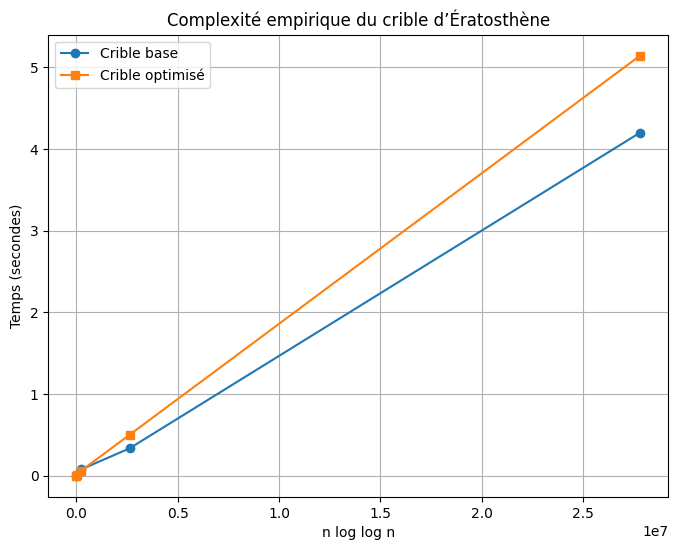

In [89]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

**Reponse** : Le graphique est approximativement une droite .
On peut conclure que dans la théorie l'Ératosthène optimisé est le plus fiable que l'Ératosthène de Base;
mais on pratique c'est l'Ératosthène de Base qui est le plus pérformant

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.